In [2]:
import sys
sys.path.append('/mnt/system/spack_nfs/spack_24Q2/spack_main/var/spack/environments/python-3p9-torch2-cuda12-24Q2/.spack-env/view/lib/python3.11/site-packages')
import os
import numpy as np

import MDAnalysis as mda
import MDAnalysis.transformations as trans

from tqdm import tqdm

import ase
from ase import io

TYPES_TO_ATOMIC_NUMBERS = [8,1,6] # O, H, C for water-box system

## Load the trajectory of the system

In [3]:
runs = {
    # "Initialization": ("../data/water-box/initialization/waterbox.data", "../data/water-box/initialization/system.xtc", 1),
    # "Unbiased": ("../data/water-box/waterbox_300K_100ns/waterbox.data", "../data/water-box/waterbox_300K_100ns/system.xtc", 10),
    # "Biased": ("../md_runs/test_waterbox/md_single/waterbox.data", "../md_runs/test_waterbox/md_single/system.xtc", 1),
    # "Biased_2": ("../md_runs/run_waterbox/md_single/waterbox.data", "../md_runs/run_waterbox/md_single/system.xtc", 1),
    "Biased_3": ("../md_runs/run_waterbox_v2/md_single/waterbox.data", "../md_runs/run_waterbox_v2/md_single/system.xtc", 1),
}
systems_data = {}
for run_name, (topology_file, trajectory_file, read_step) in runs.items():
    u = mda.Universe(topology_file, trajectory_file)

    for i in range(len(u.atoms)):
        u.atoms[i].type = str(TYPES_TO_ATOMIC_NUMBERS[int(u.atoms[i].type) - 1])
        dir(u.atoms[i])

    center_atom = u.select_atoms("type 6")
    system = u.select_atoms("all")
    # neighbours = u.select_atoms("type 1 or type 8")
    neighbours = u.select_atoms("type 8")
    transforms = [
        trans.center_in_box(center_atom, center='geometry'),
        trans.wrap(neighbours, compound='residues')
        ]
    u.trajectory.add_transformations(*transforms)
    atns = [int(atom.type) for atom in system.atoms]
    systems_data[run_name] = {}
    systems_data[run_name]['universe'] = u
    systems_data[run_name]['read_step'] = read_step
    systems_data[run_name]['center_atom'] = center_atom
    systems_data[run_name]['neighbours'] = neighbours
    systems_data[run_name]['atns'] = atns
    systems_data[run_name]['run_folder'] = os.path.dirname(trajectory_file)

## Calculate and plot the radial density function

In [4]:
from MDAnalysis.analysis.rdf import InterRDF

for run_name in runs.keys():
    print(f"Calculating RDF for run: {run_name}")
    u = systems_data[run_name]['universe']
    center_atom = systems_data[run_name]['center_atom']
    neighbours = systems_data[run_name]['neighbours']
    step = systems_data[run_name]['read_step']
    systems_data[run_name]['rdf'] = []
    rdf = InterRDF(center_atom, neighbours, 
                range=(0.0, 20.0), 
                nbins=100,
                norm='rdf',)
    for i in tqdm(range(0, len(u.trajectory)-1, step), desc=f"RDF {run_name}", leave=True):
        rdf.run(verbose=False, start=i, stop=i+1)
        systems_data[run_name]['rdf'].append((rdf.results.bins.copy(), rdf.results.rdf.copy()))

Calculating RDF for run: Biased_3


RDF Biased_3: 100%|██████████| 22734/22734 [07:12<00:00, 52.59it/s]


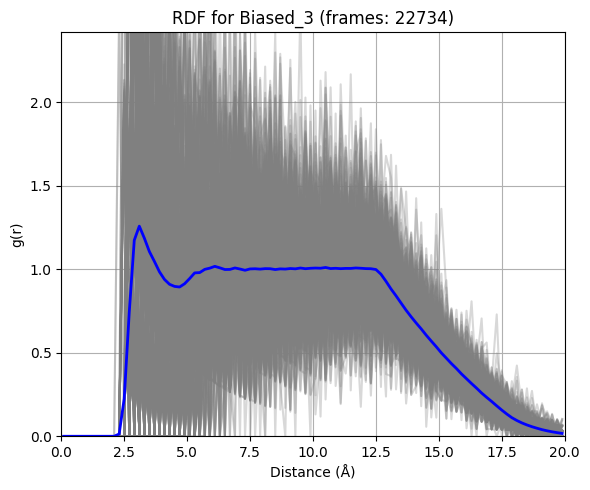

In [5]:
import matplotlib.pyplot as plt

n_runs = len(runs)
fig, axs = plt.subplots(1, n_runs, figsize=(6*n_runs,5), squeeze=False)
max_val = 2.2
for i, run_name in enumerate(runs.keys()):
    rdf = systems_data[run_name]['rdf']
    bins = rdf[0][0]
    for frame in range(0, len(rdf), 100):
        bins, values = rdf[frame]
        axs[0][i].plot(bins, values, color='gray', alpha=0.3)
    
    all_rdfs = np.array([r[1] for r in rdf])
    sum_rdf = np.mean(all_rdfs, axis=0)
    axs[0][i].plot(bins, sum_rdf, color='blue', linewidth=2, label='Sum RDF')

    axs[0][i].set_xlabel("Distance (Å)")
    axs[0][i].set_ylabel("g(r)")
    axs[0][i].set_xlim(0, 20)
    max_val = max(max_val, np.max(sum_rdf))
    axs[0][i].set_title(f"RDF for {run_name} (frames: {len(rdf)})")
    axs[0][i].grid()
for i in range(n_runs):
    axs[0][i].set_ylim(0, max_val*1.1)
fig.tight_layout()
if len(systems_data) == 1:
    fig.savefig(os.path.join(systems_data[run_name]['run_folder'], "rdf.png"), dpi=300)
plt.show()


## Calculate and plot the angular distribution function

In [6]:
for run_name in runs.keys():
    u = systems_data[run_name]['universe']
    center_atom = systems_data[run_name]['center_atom']
    neighbours = systems_data[run_name]['neighbours']
    step = systems_data[run_name]['read_step']
    theta = [] # Angle from z-axis
    phi = [] # Angle in xy-plane (azimuthal angle)
    for ts in tqdm(u.trajectory[::step], desc=f"Processing frames for {run_name}"):
        ca = center_atom.positions[0]
        for atom in neighbours:
            vec = atom.position - ca
            r = np.linalg.norm(vec)
            if r > 0:
                theta.append(np.arccos(vec[2]/r)) 
                phi.append(np.arctan2(vec[1], vec[0]))
    theta = np.array(theta)
    phi = np.array(phi)

    systems_data[run_name]['theta'] = theta
    systems_data[run_name]['phi'] = phi

Processing frames for Biased_3: 100%|█████████▉| 22734/22735 [07:10<00:00, 52.84it/s]


Plotting angular distribution for run: Biased_3


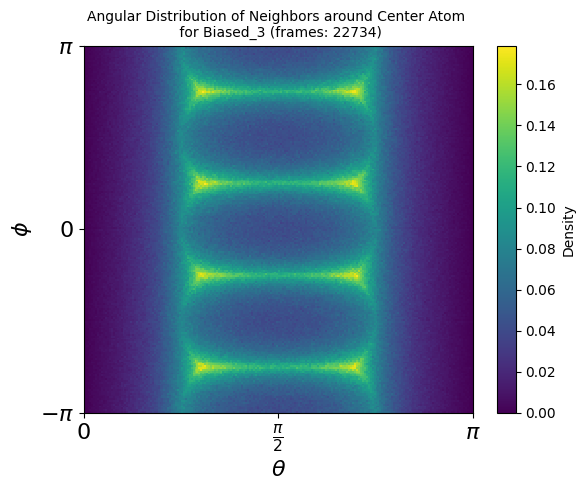

In [7]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, len(runs), figsize=(6*len(runs),5), squeeze=False)

for i, run_name in enumerate(runs.keys()):
    print(f"Plotting angular distribution for run: {run_name}")
    theta = systems_data[run_name]['theta']
    phi = systems_data[run_name]['phi']
    p = axs[0][i].hist2d(theta, phi, bins=200, density=True, cmap='viridis')
    plt.colorbar(p[3], ax=axs[0][i], label='Density')
    axs[0][i].set_xlabel(r'$\theta$', fontsize=16)
    axs[0][i].set_ylabel(r'$\phi$', fontsize=16)
    axs[0][i].set_xlim(0, np.pi)
    axs[0][i].set_ylim(-np.pi, np.pi)
    axs[0][i].set_xticks([0, np.pi/2, np.pi], [r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'], fontsize=16)
    axs[0][i].set_yticks([-np.pi, 0, np.pi], [r'$-\pi$', r'$0$', r'$\pi$'], fontsize=16)
    axs[0][i].set_title('Angular Distribution of Neighbors around Center Atom \n for ' + run_name + ' (frames: ' + str(len(systems_data[run_name]['rdf'])) + ')', fontsize=10)

    if len(systems_data) == 1:
        fig.savefig(os.path.join(systems_data[run_name]['run_folder'], "angular_distribution.png"), dpi=300)
fig.tight_layout()
plt.show()